# Реализовать архитектуру LeNet5.
1. Обучить на данных MNIST
2. Визуализировать карты признаков

![Architecture-of-LeNet-5.jpg](attachment:Architecture-of-LeNet-5.jpg)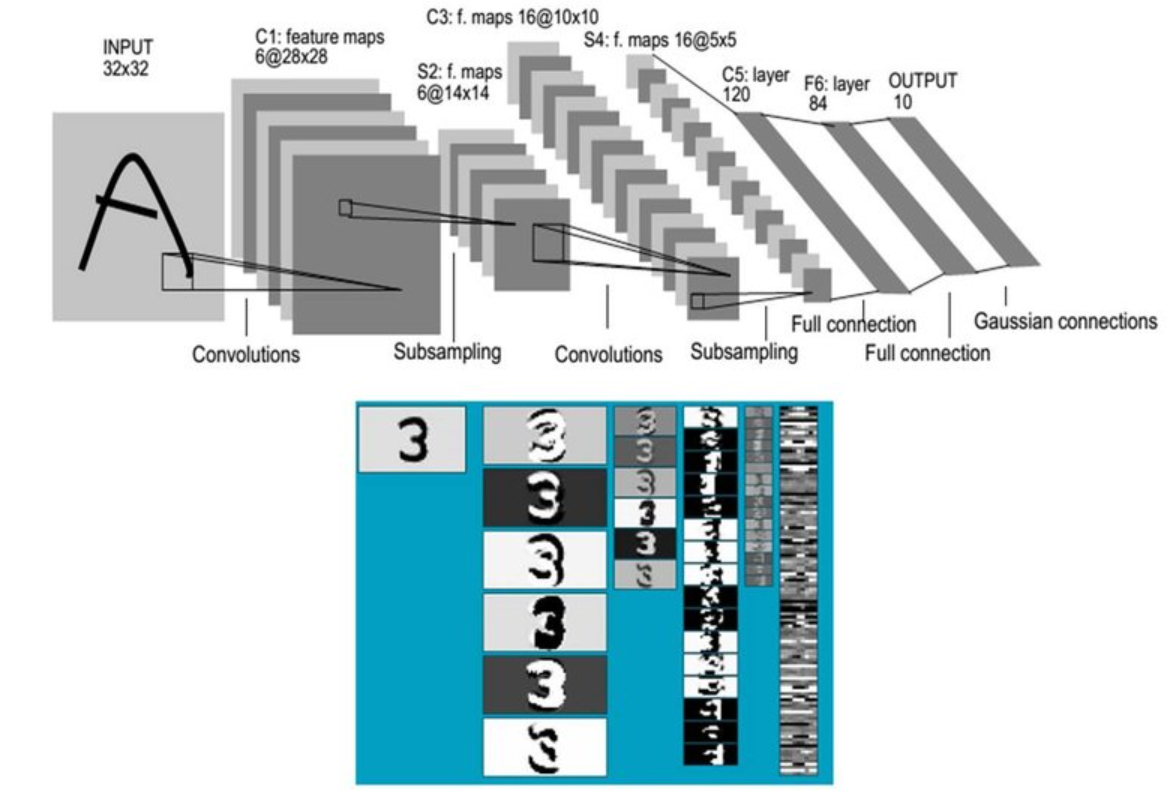

In [1]:
import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [2]:
import torchvision.datasets

In [3]:
MNIST_train = torchvision.datasets.MNIST('./', download=False, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=False, train=False)


In [4]:
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

In [5]:
len(y_train), len(y_test)

(60000, 10000)

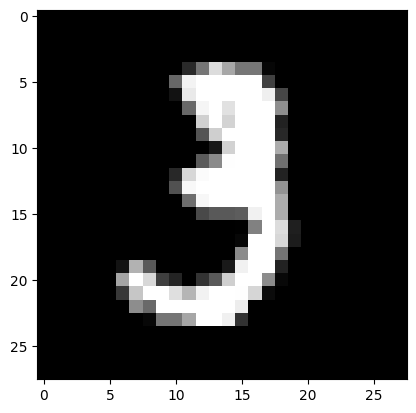

tensor(3)


In [6]:
import matplotlib.pyplot as plt
plt.imshow(X_train[10, :, :])
plt.gray()
plt.show()
print(y_train[10])

In [7]:
X_train = X_train.unsqueeze(1).float()
X_test = X_test.unsqueeze(1).float()

In [8]:
X_train.shape

torch.Size([60000, 1, 28, 28])

In [9]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
    #torch.nn.Conv2d(in_channels=, out_channels=, kernel_size=, padding=)
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1  = torch.nn.Tanh()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2  = torch.nn.Tanh()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3  = torch.nn.Tanh()
        self.fc2   = torch.nn.Linear(120, 84)
        self.act4  = torch.nn.Tanh()
        self.fc3   = torch.nn.Linear(84, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)
        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))
        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)
        return x



In [10]:
lenet5 = LeNet5()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
lenet5 = lenet5.to(device)

In [11]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [12]:
batch_size = 100
num_epochs = 25

test_accuracy_history = []
test_loss_history = []

X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(num_epochs):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()

        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        preds = lenet5.forward(X_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()

        optimizer.step()

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())

    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(accuracy)

tensor(0.9754)
tensor(0.9832)
tensor(0.9858)
tensor(0.9871)
tensor(0.9883)
tensor(0.9886)
tensor(0.9895)
tensor(0.9903)
tensor(0.9885)
tensor(0.9886)
tensor(0.9872)
tensor(0.9897)
tensor(0.9894)
tensor(0.9893)
tensor(0.9890)
tensor(0.9868)
tensor(0.9904)
tensor(0.9892)
tensor(0.9886)
tensor(0.9892)
tensor(0.9865)
tensor(0.9875)
tensor(0.9905)
tensor(0.9878)
tensor(0.9893)


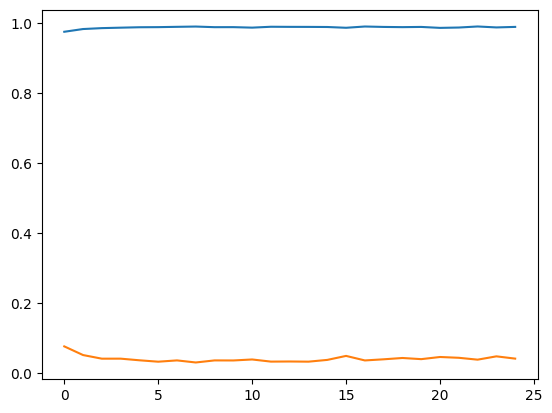

In [13]:
plt.plot(test_accuracy_history);
plt.plot(test_loss_history);

In [14]:
# Задание 2
# Визуализировать карты признаков для входного изображения на каждом слое до и после обучения.

In [15]:
# X_train[0, :, :].shape
# X_batch = X_train[[1,1]]
X_batch = X_train[1].unsqueeze(1)
X_batch.shape

torch.Size([1, 1, 28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

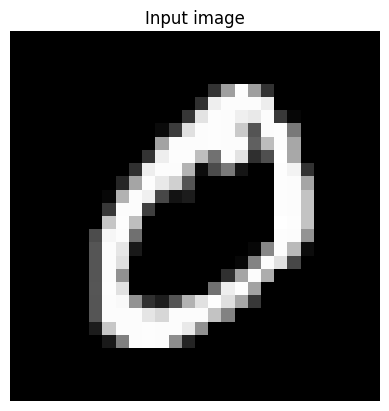

In [16]:
import matplotlib.pyplot as plt
plt.gray()
plt.title('Input image')
plt.imshow(X_batch[0][0].data.cpu())
plt.axis('off')

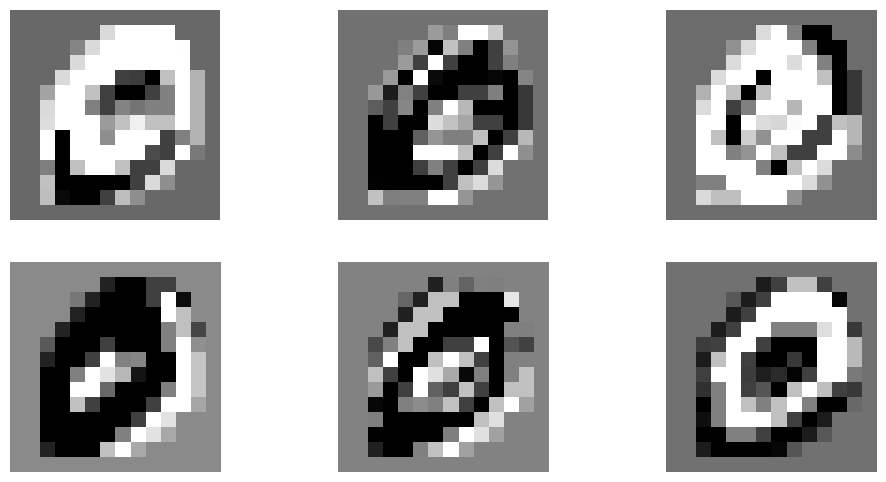

In [17]:
# Карты признаков 1 слоя
with torch.no_grad():
    feature_maps_1 = lenet5.pool1(lenet5.act1(lenet5.conv1(X_batch.to(device)))).cpu()

plt.figure(figsize=(12, 6))
for i in range(feature_maps_1.shape[1]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(feature_maps_1[0, i], cmap='gray')
    plt.axis('off')
plt.show()

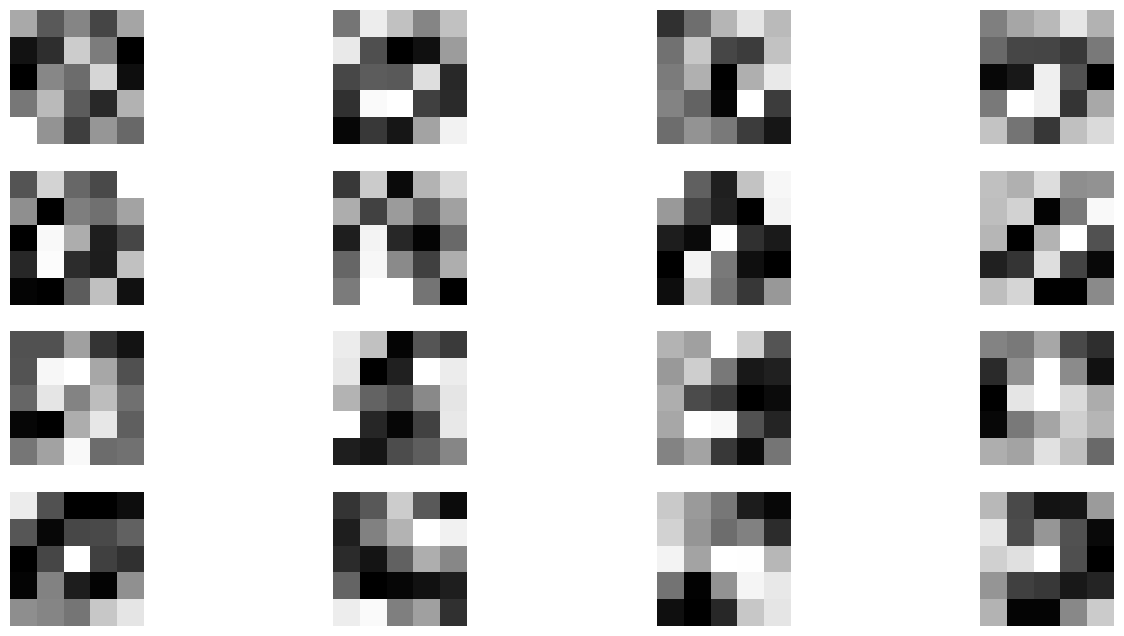

In [18]:
# Карты признаков 2 слоя
with torch.no_grad():
    x = lenet5.pool1(lenet5.act1(lenet5.conv1(X_batch.to(device))))
    feature_maps_2 = lenet5.pool2(lenet5.act2(lenet5.conv2(x))).cpu()

plt.figure(figsize=(16, 8))
for i in range(feature_maps_2.shape[1]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps_2[0, i], cmap='gray')
    plt.axis('off')
plt.show()